In [6]:
import os
import re
import pandas as pd
from pathlib import Path

In [7]:
from src.cell_track_analysis.live_image_utils import extract_tracks
from src.cell_track_analysis.utils import extract_wells_info

# Visualisation ERKKTR ratio

In [4]:
path = r"/mnt/nas/group/REPORT/Imaging/2025-05-29-namirine-A549 ERKKTR mRUBY clone4, RSV NB6 MOI=2, 20"

In [115]:
def extract_well(rootdir, n=1):
    print(rootdir)
    tracks = pd.DataFrame()
    for name in os.listdir(rootdir):
        subdir = os.path.join(rootdir, name)
        if os.path.isdir(subdir) and re.fullmatch(r"\d{4}-ST", subdir.split('/')[-1]):
            
            well_tracks = extract_tracks(subdir)
            well_tracks['All tracks'] = len(well_tracks)
            well_tracks['Eligible tracks'] = len(well_tracks[well_tracks['track_length']>n])
            tracks = pd.concat((tracks, well_tracks), axis=0)
    #print('All tracks:', len(tracks.groupby(['track_index', 'experiment', 'well'])))
    #tracks = tracks[tracks['track_length']>n]
    #print('Eligible tracks:', tracks.groupby(['track_index', 'experiment', 'well']).count().drop_duplicates())

    print('merging')
    tracks = pd.merge(tracks.reset_index(), extract_wells_info(rootdir), on=['well', 'experiment'])
    #track_stats = pd.merge(track_stats.reset_index(), tracks[['well', 'experiment', 'All tracks', 'Eligible tracks']], on=['well', 'experiment'], how='left')
    return tracks


tracks = extract_well(path)

/mnt/nas/group/REPORT/Imaging/2025-05-29-namirine-A549 ERKKTR mRUBY clone4, RSV NB6 MOI=2, 20
   corresp_nucleus_id   area  H2B_intensity_min  H2B_intensity_max  \
0                   1  130.0                7.0               27.0   
1                   2  166.5                7.0               32.0   
2                   3  134.0                8.0               55.0   
3                   4  175.0               10.0               42.0   
4                   5  149.0                8.0               35.0   

   H2B_intensity_median  H2B_intensity_quartile1  H2B_intensity_quartile3  \
0                  16.0                     14.0                     18.0   
1                  17.0                     15.0                     19.0   
2                  17.0                     14.0                     20.0   
3                  17.0                     15.0                     19.0   
4                  17.0                     15.0                     20.0   

   H2B_intensity_mean 

In [25]:
tracks[['track_index', 'time_point_index', 'nucleus_id', 'center_y', 'center_x', 'area',
       'H2B_intensity_mean', 'H2B_intensity_sum',
       'H2B_intensity_max', 'H2B_intensity_min',
       'ERKKTR_intensity_mean', 'ERKKTR_intensity_sum',
       'ERKKTR_intensity_max', 'ERKKTR_intensity_min', 'area_per',
       'H2B_intensity_mean_per', 'H2B_intensity_sum_per',
       'H2B_intensity_max_per', 'H2B_intensity_min_per',
       'ERKKTR_intensity_mean_per', 'ERKKTR_intensity_sum_per',
       'ERKKTR_intensity_max_per', 'ERKKTR_intensity_min_per', 'well', 'track_length',
 'experiment',
 'well',
 'Row',
 'Column',
 'Virus',
 'CellType1',
 'CellType2']].rename({'Virus': 'Serum',
 'CellType1': 'treatments',
 'CellType2': 'CellLine'}, axis=1).dropna().to_csv(os.path.join(path, 'quantifications.csv'))#.dropna()

In [54]:
df_list = []
for df_path in ['2025-05-290205-Stitches_df.csv', '2025-05-290305-Stitches_df.csv', '2025-05-290306-Stitches_df.csv','2025-05-290307-Stitches_df.csv']:
    df_list. append(pd.read_csv(os.path.join('/mnt/data', df_path)))

In [55]:
for df in df_list:
    print(len(df))

866652
839704
852252
672885


In [62]:
df_list[0]['well'] = '0205'
df_list[1]['well'] = '0305'
df_list[2]['well'] = '0306'
df_list[3]['well'] = '0307'

In [3]:
wells_info = extract_wells_info(r"/mnt/nas/group/REPORT/Imaging/2025-05-29-namirine-A549 ERKKTR mRUBY clone4, RSV NB6 MOI=2, 20")

In [4]:
wells_info

,,,WellId,Serum,treatments,CellType1,experiment
0,2,5,0205,0.3% BSA,Medium,A549 WT ERKKTR mRUBY-4 H2B-miRFP703,/mnt/nas/group/REPORT/Imaging/2025-05-29-namir...
1,3,5,0305,0.3% BSA,EGF,A549 WT ERKKTR mRUBY-4 H2B-miRFP703,/mnt/nas/group/REPORT/Imaging/2025-05-29-namir...
2,3,6,0306,0.3% BSA,RSV MOI=2,A549 WT ERKKTR mRUBY-4 H2B-miRFP703,/mnt/nas/group/REPORT/Imaging/2025-05-29-namir...
3,3,7,0307,0.3% BSA,RSV MOI=20,A549 WT ERKKTR mRUBY-4 H2B-miRFP703,/mnt/nas/group/REPORT/Imaging/2025-05-29-namir...


In [76]:
df = pd.read_csv(r"/mnt/nas/group/REPORT/Imaging/2025-05-29-namirine-A549 ERKKTR mRUBY clone4, RSV NB6 MOI=2, 20/quantifications_pawels_script.csv")

In [113]:
df_st = pd.read_csv(r"/mnt/nas/group/REPORT/Imaging/2025-05-29-namirine-A549 ERKKTR mRUBY clone4, RSV NB6 MOI=2, 20/quantifications.csv")


In [80]:
df['well'] = df['well'].apply(lambda x: '0'+str(x))

In [81]:
df = pd.concat(df_list).merge(wells_info, on='well', how='left')

In [ ]:
df['ERKKTR_ratio'] = df['per_ERKKTR_intensity_mean']/df['nuc_ERKKTR_intensity_mean']
m = df[df['frame']==42].groupby('well')['ERKKTR_ratio'].mean()

df['ERKKTR_ratio_norm'] = df.apply(lambda x: x['ERKKTR_ratio']/m[x['well']], axis=1)

def ratio_of_responders(df_erk):
    df = df_erk.copy()

    df['above'] = df['ERKKTR_ratio_norm']<1
    return df.groupby('frame')['above'].mean().apply(lambda x: 2*x if 2*x<1 else 1).reset_index()

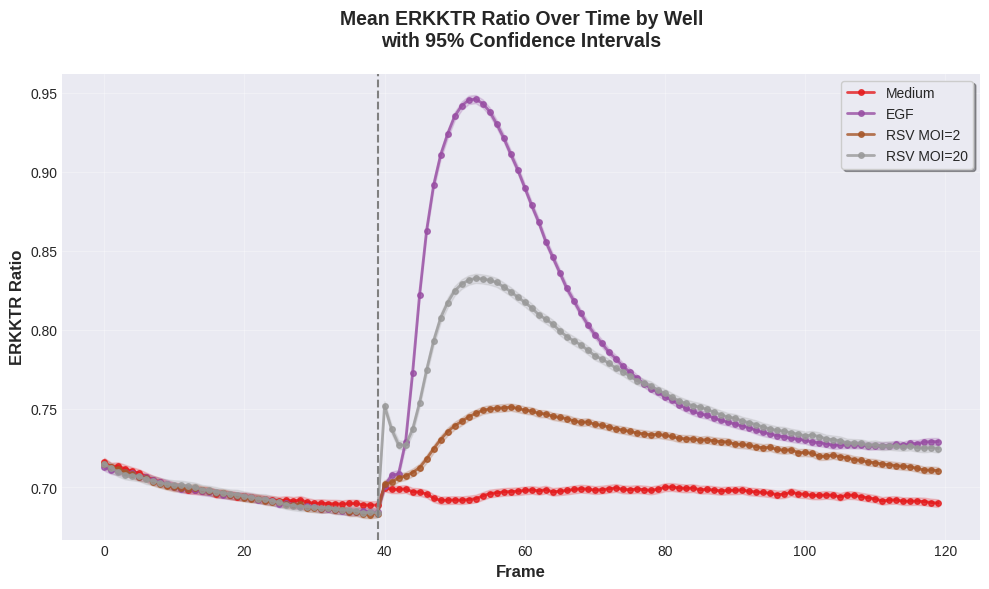

In [96]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats

# Set style for better aesthetics
plt.style.use('seaborn-v0_8-darkgrid')  # or 'seaborn-v0_8-whitegrid'
colors = plt.cm.Set1(np.linspace(0, 1, df['well'].nunique()))

fig, ax = plt.subplots(figsize=(10, 6))

for i, (well_id, well) in enumerate(df.groupby('well')):
    # Group by frame and calculate statistics
    frame_stats = well.groupby('frame')['ERKKTR_ratio'].agg([
        'mean', 'std', 'sem', 'count'
    ]).reset_index()
    
    # Calculate 95% confidence intervals using SEM and t-distribution
    confidence_level = 0.95
    alpha = 1 - confidence_level
    
    # Use t-distribution for small sample sizes, normal for large
    ci_multiplier = np.where(
        frame_stats['count'] < 30,
        stats.t.ppf(1 - alpha/2, frame_stats['count'] - 1),
        stats.norm.ppf(1 - alpha/2)
    )
    
    ci = ci_multiplier * frame_stats['sem']
    
    # Plot line with semi-transparent confidence interval
    color = colors[i]
    
    treatment = well['CellType1'].iloc[0]

    # Main line
    ax.plot(frame_stats['frame'], frame_stats['mean'], 
            color=color, linewidth=2, label=treatment, 
            marker='o', markersize=4, alpha=0.8)
    
    # Semi-transparent confidence interval
    ax.fill_between(frame_stats['frame'], 
                    frame_stats['mean'] - ci,
                    frame_stats['mean'] + ci,
                    color=color, alpha=0.2, 
                    label=f'Well {well_id} 95% CI')
ax.axvline(x = 39, color='grey', linestyle='--')
# Styling
ax.set_xlabel('Frame', fontsize=12, fontweight='bold')
ax.set_ylabel('ERKKTR Ratio', fontsize=12, fontweight='bold')
ax.set_title('Mean ERKKTR Ratio Over Time by Well\nwith 95% Confidence Intervals', 
             fontsize=14, fontweight='bold', pad=20)

# Legend with only main lines (not CI)
handles, labels = ax.get_legend_handles_labels()
# Keep only every other handle/label (the main lines, not CI)
main_handles = handles[::2]
main_labels = labels[::2]
ax.legend(main_handles, main_labels, loc='best', frameon=True, 
          fancybox=True, shadow=True)

# Grid and layout
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


In [116]:
tracks

,level_0,track_index,time_point_index,nucleus_id,area,area_masked,eccentricity,is_toggled,center_x,center_y,...,label,experiment,well,All tracks,Eligible tracks,Row,Column,Virus,CellType1,CellType2
0,0,0,0,1720,403.5,0.0,0.110,0,128.45,1293.41,...,None,/mnt/nas/group/REPORT/Imaging/2025-05-29-namir...,0205,777102,762658,2,5,0.3% BSA,Medium,A549 WT ERKKTR mRUBY-4 H2B-miRFP703
1,1,0,1,1753,401.0,0.0,0.117,0,128.63,1294.09,...,None,/mnt/nas/group/REPORT/Imaging/2025-05-29-namir...,0205,777102,762658,2,5,0.3% BSA,Medium,A549 WT ERKKTR mRUBY-4 H2B-miRFP703
2,2,0,2,1741,408.0,0.0,0.108,0,128.26,1293.16,...,None,/mnt/nas/group/REPORT/Imaging/2025-05-29-namir...,0205,777102,762658,2,5,0.3% BSA,Medium,A549 WT ERKKTR mRUBY-4 H2B-miRFP703
3,3,0,3,1722,411.5,0.0,0.124,0,128.08,1293.47,...,None,/mnt/nas/group/REPORT/Imaging/2025-05-29-namir...,0205,777102,762658,2,5,0.3% BSA,Medium,A549 WT ERKKTR mRUBY-4 H2B-miRFP703
4,4,0,4,1708,399.5,0.0,0.114,0,127.92,1293.73,...,None,/mnt/nas/group/REPORT/Imaging/2025-05-29-namir...,0205,777102,762658,2,5,0.3% BSA,Medium,A549 WT ERKKTR mRUBY-4 H2B-miRFP703
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2920310,622362,36999,106,3126,425.5,0.0,0.209,0,382.87,1880.42,...,None,/mnt/nas/group/REPORT/Imaging/2025-05-29-namir...,0307,622367,606245,3,7,0.3% BSA,RSV MOI=20,A549 WT ERKKTR mRUBY-4 H2B-miRFP703
2920311,622363,37000,10,4139,641.0,0.0,0.235,0,2088.60,403.74,...,None,/mnt/nas/group/REPORT/Imaging/2025-05-29-namir...,0307,622367,606245,3,7,0.3% BSA,RSV MOI=20,A549 WT ERKKTR mRUBY-4 H2B-miRFP703
2920312,622364,37001,102,3567,413.0,0.0,0.057,0,42.34,1151.87,...,None,/mnt/nas/group/REPORT/Imaging/2025-05-29-namir...,0307,622367,606245,3,7,0.3% BSA,RSV MOI=20,A549 WT ERKKTR mRUBY-4 H2B-miRFP703
2920313,622365,37002,116,3694,311.0,0.0,0.106,0,1785.99,1063.45,...,None,/mnt/nas/group/REPORT/Imaging/2025-05-29-namir...,0307,622367,606245,3,7,0.3% BSA,RSV MOI=20,A549 WT ERKKTR mRUBY-4 H2B-miRFP703


<Axes: xlabel='time_point_index'>

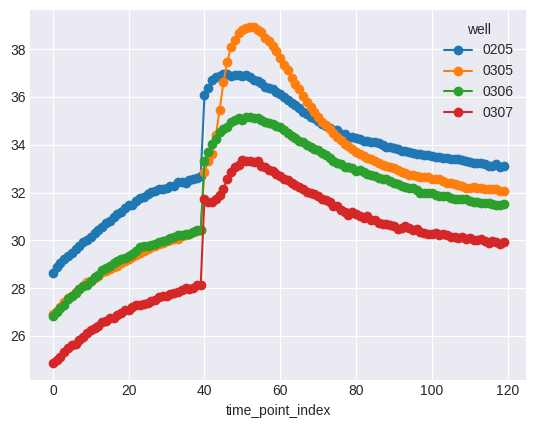

In [123]:
tracks.groupby(['well', 'time_point_index'])['ERKKTR_intensity_mean_per'].mean().unstack('well').plot(marker='o')


<Axes: xlabel='time_point_index'>

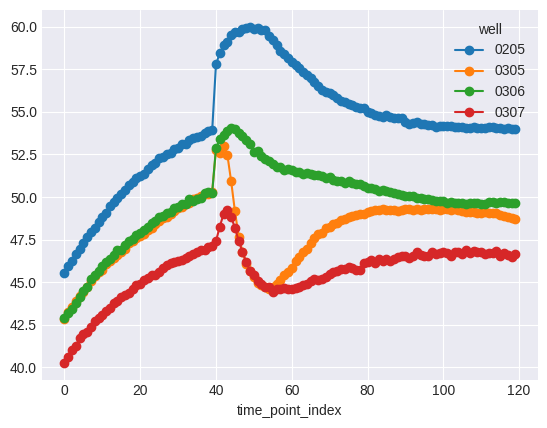

In [122]:
tracks.groupby(['well', 'time_point_index'])['ERKKTR_intensity_mean'].mean().unstack('well').plot(marker='o')

<Axes: xlabel='time_point_index'>

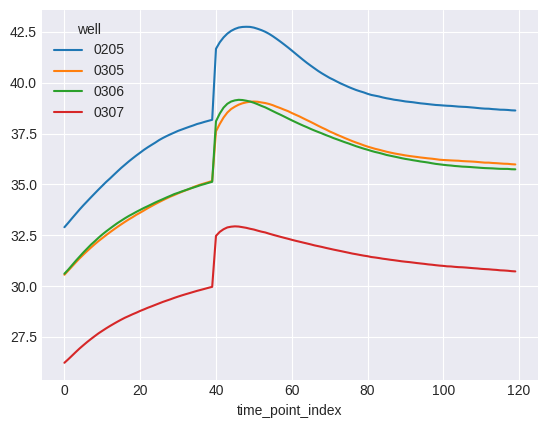

In [118]:
tracks.groupby(['well', 'time_point_index'])['ERKKTR_intensity_mean_img'].mean().unstack('well').plot()

<Axes: xlabel='time_point_index'>

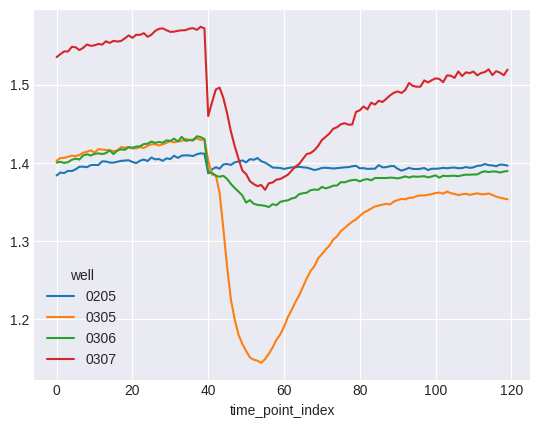

In [119]:
tracks['ERKKTR_nuc_img'] = tracks['ERKKTR_intensity_mean']/tracks['ERKKTR_intensity_mean_img']
tracks.groupby(['well', 'time_point_index'])['ERKKTR_nuc_img'].mean().unstack('well').plot()


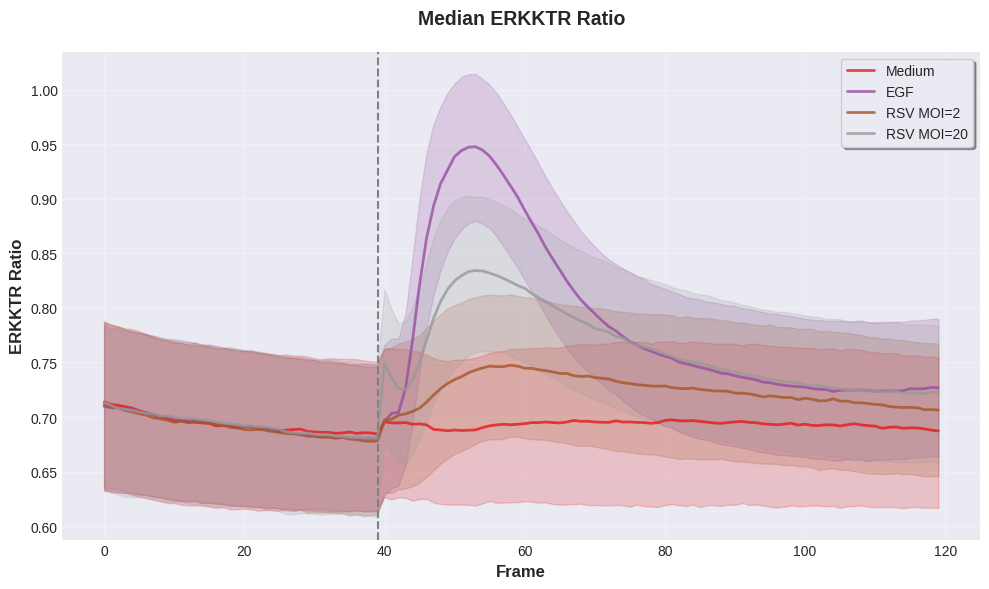

In [97]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats

# Set style for better aesthetics
plt.style.use('seaborn-v0_8-darkgrid')  # or 'seaborn-v0_8-whitegrid'
colors = plt.cm.Set1(np.linspace(0, 1, df['well'].nunique()))

fig, ax = plt.subplots(figsize=(10, 6))

for i, (well_id, well) in enumerate(df.groupby('well')):
    # Group by frame and calculate statistics
    frame_stats = well.groupby('frame')['ERKKTR_ratio'].agg([
        'median', lambda x: x.quantile(0.25),  lambda x: x.quantile(0.75)
    ]).reset_index().rename({'<lambda_0>': '1st_quantile', '<lambda_1>': '3rd_quantile'},axis=1)
    
    # Plot line with semi-transparent confidence interval
    color = colors[i]
    
    treatment = well['CellType1'].iloc[0]

    # Main line
    ax.plot(frame_stats['frame'], frame_stats['median'], 
            color=color, linewidth=2, label=treatment, 
             alpha=0.8)
    
    # Semi-transparent confidence interval
    ax.fill_between(frame_stats['frame'], 
                    frame_stats['1st_quantile'],
                    frame_stats['3rd_quantile'],
                    color=color, alpha=0.2, 
                    label=f'Well {well_id} 95% CI')
ax.axvline(x = 39, color='grey', linestyle='--')
# Styling
ax.set_xlabel('Frame', fontsize=12, fontweight='bold')
ax.set_ylabel('ERKKTR Ratio', fontsize=12, fontweight='bold')
ax.set_title('Median ERKKTR Ratio', 
             fontsize=14, fontweight='bold', pad=20)

# Legend with only main lines (not CI)
handles, labels = ax.get_legend_handles_labels()
# Keep only every other handle/label (the main lines, not CI)
main_handles = handles[::2]
main_labels = labels[::2]
ax.legend(main_handles, main_labels, loc='best', frameon=True, 
          fancybox=True, shadow=True)

# Grid and layout
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()#savefig('/mnt/nas/group/pkaczyns/ERKKTR/')

In [ ]:
df[df['frame']==42].groupby('well')['ERKKTR_ratio'].mean()#.hist(alpha=0.2)

well
0205    0.698750
0305    0.708608
0306    0.706101
0307    0.727184
Name: ERKKTR_ratio, dtype: float64

<Axes: xlabel='frame'>

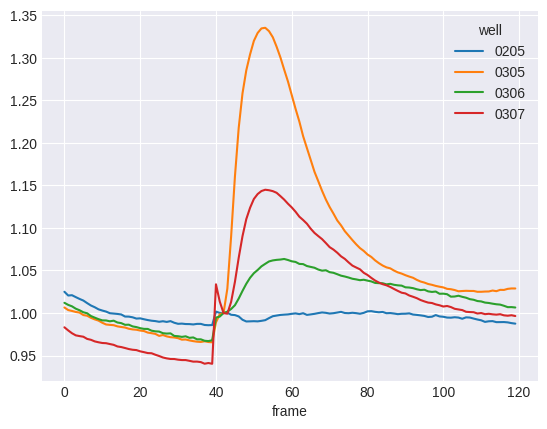

In [159]:
df.groupby(['well', 'frame'])['ERKKTR_ratio_norm'].mean().unstack('well').plot()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats

def plot_erkktr_with_confidence_intervals(df, t_add, ax=None, show_plot=True):
    """
    Plot ERKKTR ratio over time by well with 95% confidence intervals.
    
    Parameters:
    df: DataFrame with columns ['well', 'frame', 'ERKKTR_ratio']
    t_add: time point for vertical line
    ax: matplotlib axis object (optional)
    show_plot: whether to show the plot (default True)
    
    Returns:
    fig, ax: matplotlib figure and axis objects
    """
    if ax is None:
        plt.style.use('seaborn-v0_8-darkgrid')
        fig, ax = plt.subplots(figsize=(10, 6))
    else:
        fig = ax.figure
    
    colors = plt.cm.Set1(np.linspace(0, 1, df['well'].nunique()))
    
    for i, (well_id, well) in enumerate(df.groupby('well')):
        # Group by frame and calculate statistics
        frame_stats = well.groupby('frame')['ERKKTR_ratio'].agg([
            'mean', 'std', 'sem', 'count'
        ]).reset_index()
        
        # Calculate 95% confidence intervals using SEM and t-distribution
        confidence_level = 0.95
        alpha = 1 - confidence_level
        # Use t-distribution for small sample sizes, normal for large
        ci_multiplier = np.where(
            frame_stats['count'] < 30,
            stats.t.ppf(1 - alpha/2, frame_stats['count'] - 1),
            stats.norm.ppf(1 - alpha/2)
        )
        ci = ci_multiplier * frame_stats['sem']
        
        # Plot line with semi-transparent confidence interval
        color = colors[i]
        # Main line
        ax.plot(frame_stats['frame'], frame_stats['mean'],
                color=color, linewidth=2, label=f'Well {well_id}',
                marker='o', markersize=4, alpha=0.8)
        # Semi-transparent confidence interval
        ax.fill_between(frame_stats['frame'],
                       frame_stats['mean'] - ci,
                       frame_stats['mean'] + ci,
                       color=color, alpha=0.2,
                       label=f'Well {well_id} 95% CI')
    
    ax.axvline(x=t_add, color='grey', linestyle='--')
    # Styling
    ax.set_xlabel('Frame', fontsize=12, fontweight='bold')
    ax.set_ylabel('ERKKTR Ratio', fontsize=12, fontweight='bold')
    ax.set_title('Mean ERKKTR Ratio',
                fontsize=14, fontweight='bold', pad=20)
    
    # Legend with only main lines (not CI)
    handles, labels = ax.get_legend_handles_labels()
    # Keep only every other handle/label (the main lines, not CI)
    main_handles = handles[::2]
    main_labels = labels[::2]
    ax.legend(main_handles, main_labels, loc='best', frameon=True,
             fancybox=True, shadow=True)
    
    # Grid and layout
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    if show_plot:
        plt.tight_layout()
        plt.show()
    
    return fig, ax

def plot_median_erkktr(df, t_add, ax=None, show_plot=True):
    """
    Plot median ERKKTR ratio with quartiles.
    
    Parameters:
    df: DataFrame with columns ['well', 'frame', 'ERKKTR_ratio', 'CellType1']
    t_add: time point for vertical line
    ax: matplotlib axis object (optional)
    show_plot: whether to show the plot (default True)
    
    Returns:
    fig, ax: matplotlib figure and axis objects
    """
    if ax is None:
        plt.style.use('seaborn-v0_8-darkgrid')
        fig, ax = plt.subplots(figsize=(10, 6))
    else:
        fig = ax.figure
    
    colors = plt.cm.Set1(np.linspace(0, 1, df['well'].nunique()))
    
    for i, (well_id, well) in enumerate(df.groupby('well')):
        # Group by frame and calculate statistics
        frame_stats = well.groupby('frame')['ERKKTR_ratio'].agg([
            'median', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)
        ]).reset_index().rename({'<lambda_0>': '1st_quantile', '<lambda_1>': '3rd_quantile'}, axis=1)
        
        # Plot line with semi-transparent confidence interval
        color = colors[i]
        treatment = well['CellType1'].iloc[0]
        
        # Main line
        ax.plot(frame_stats['frame'], frame_stats['median'],
                color=color, linewidth=2, label=treatment,
                alpha=0.8)
        
        # Semi-transparent confidence interval
        ax.fill_between(frame_stats['frame'],
                       frame_stats['1st_quantile'],
                       frame_stats['3rd_quantile'],
                       color=color, alpha=0.2,
                       label=f'Well {well_id} 95% CI')
    
    ax.axvline(x=t_add, color='grey', linestyle='--')
    
    # Styling
    ax.set_xlabel('Frame', fontsize=12, fontweight='bold')
    ax.set_ylabel('ERKKTR Ratio', fontsize=12, fontweight='bold')
    ax.set_title('Median ERKKTR Ratio',
                fontsize=14, fontweight='bold', pad=20)
    
    # Legend with only main lines (not CI)
    handles, labels = ax.get_legend_handles_labels()
    # Keep only every other handle/label (the main lines, not CI)
    main_handles = handles[::2]
    main_labels = labels[::2]
    ax.legend(main_handles, main_labels, loc='best', frameon=True,
             fancybox=True, shadow=True)
    
    # Grid and layout
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    if show_plot:
        plt.tight_layout()
        plt.show()
    
    return fig, ax

def plot_proportion_non_responders(df, t_add, ax=None, show_plot=True):
    """
    Plot estimated proportion of non-responders.
    
    Parameters:
    df: DataFrame with columns ['well', 'CellType1']
    t_add: time point for vertical line
    ax: matplotlib axis object (optional)
    show_plot: whether to show the plot (default True)
    
    Returns:
    fig, ax: matplotlib figure and axis objects
    """
    if ax is None:
        plt.style.use('seaborn-v0_8-darkgrid')
        fig, ax = plt.subplots(figsize=(10, 6))
    else:
        fig = ax.figure
    
    colors = plt.cm.Set1(np.linspace(0, 1, df['well'].nunique()))
    
    for i, (well_id, well) in enumerate(df.groupby('well')):
        # Group by frame and calculate statistics
        frame_stats = ratio_of_responders(well)
        
        # Plot line
        color = colors[i]
        treatment = well['CellType1'].iloc[0]
        print(treatment)
        
        # Main line
        ax.plot(frame_stats['frame'], frame_stats['above'],
                color=color, linewidth=2, label=treatment,
                alpha=0.8)
    
    ax.axvline(x=t_add, color='grey', linestyle='--')
    
    # Styling
    ax.set_xlabel('Frame', fontsize=12, fontweight='bold')
    ax.set_ylabel('Proportion of non-responders', fontsize=12, fontweight='bold')
    ax.set_title('Estimated proportion of non-responders',
                fontsize=14, fontweight='bold', pad=20)
    
    # Legend with only main lines (not CI)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, loc='best', frameon=True,
             fancybox=True, shadow=True)
    
    # Grid and layout
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    if show_plot:
        plt.tight_layout()
        plt.show()
    
    return fig, ax

def create_combined_erkktr_plots(df, t_add, save_path='combined_erkktr_plots.png', figsize=(10, 18)):
    """
    Create all three ERKKTR plots stacked vertically and save as PNG.
    
    Parameters:
    df: DataFrame for all plots
    t_add: time point for vertical line
    save_path: path to save the combined plot
    figsize: figure size tuple (width, height)
    
    Returns:
    fig: matplotlib figure object
    """
    plt.style.use('seaborn-v0_8-darkgrid')
    fig, axes = plt.subplots(3, 1, figsize=figsize, sharex=True)
    
    # Plot 1: ERKKTR with confidence intervals
    plot_erkktr_with_confidence_intervals(df, t_add, ax=axes[0], show_plot=False)
    
    # Plot 2: Median ERKKTR
    plot_median_erkktr(df, t_add, ax=axes[1], show_plot=False)
    
    # Plot 3: Proportion of non-responders
    plot_proportion_non_responders(df, t_add, ax=axes[2], show_plot=False)
    
    # Remove individual legends from each subplot
    axes[0].legend().remove()
    axes[1].legend().remove()
    axes[2].legend().remove()
    
    # Remove x-axis labels from top two plots (since we're sharing x-axis)
    axes[0].set_xlabel('')
    axes[1].set_xlabel('')
    
    # Create a single legend at the bottom
    # Get handles and labels from the middle plot (median plot) since it has treatment labels
    handles, labels = axes[1].get_legend_handles_labels()
    main_handles = handles[::2]  # Keep only main lines, not CI
    main_labels = labels[::2]
    
    # Add the legend below the last subplot
    fig.legend(main_handles, main_labels, loc='lower center', 
               bbox_to_anchor=(0.5, 0), ncol=len(main_labels), 
               frameon=True, fancybox=True, shadow=True)
    
    # Adjust layout and save
    #plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)  # Make room for the legend
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Combined plots saved to: {save_path}")
    
    return fig

# Example usage:
# fig1, ax1 = plot_erkktr_with_confidence_intervals(df, t_add)
# fig2, ax2 = plot_median_erkktr(df, t_add)
# fig3, ax3 = plot_proportion_non_responders(df, t_add)
# combined_fig = create_combined_erkktr_plots(df, t_add, 'my_plots.png')

Medium
EGF
RSV MOI=2
RSV MOI=20


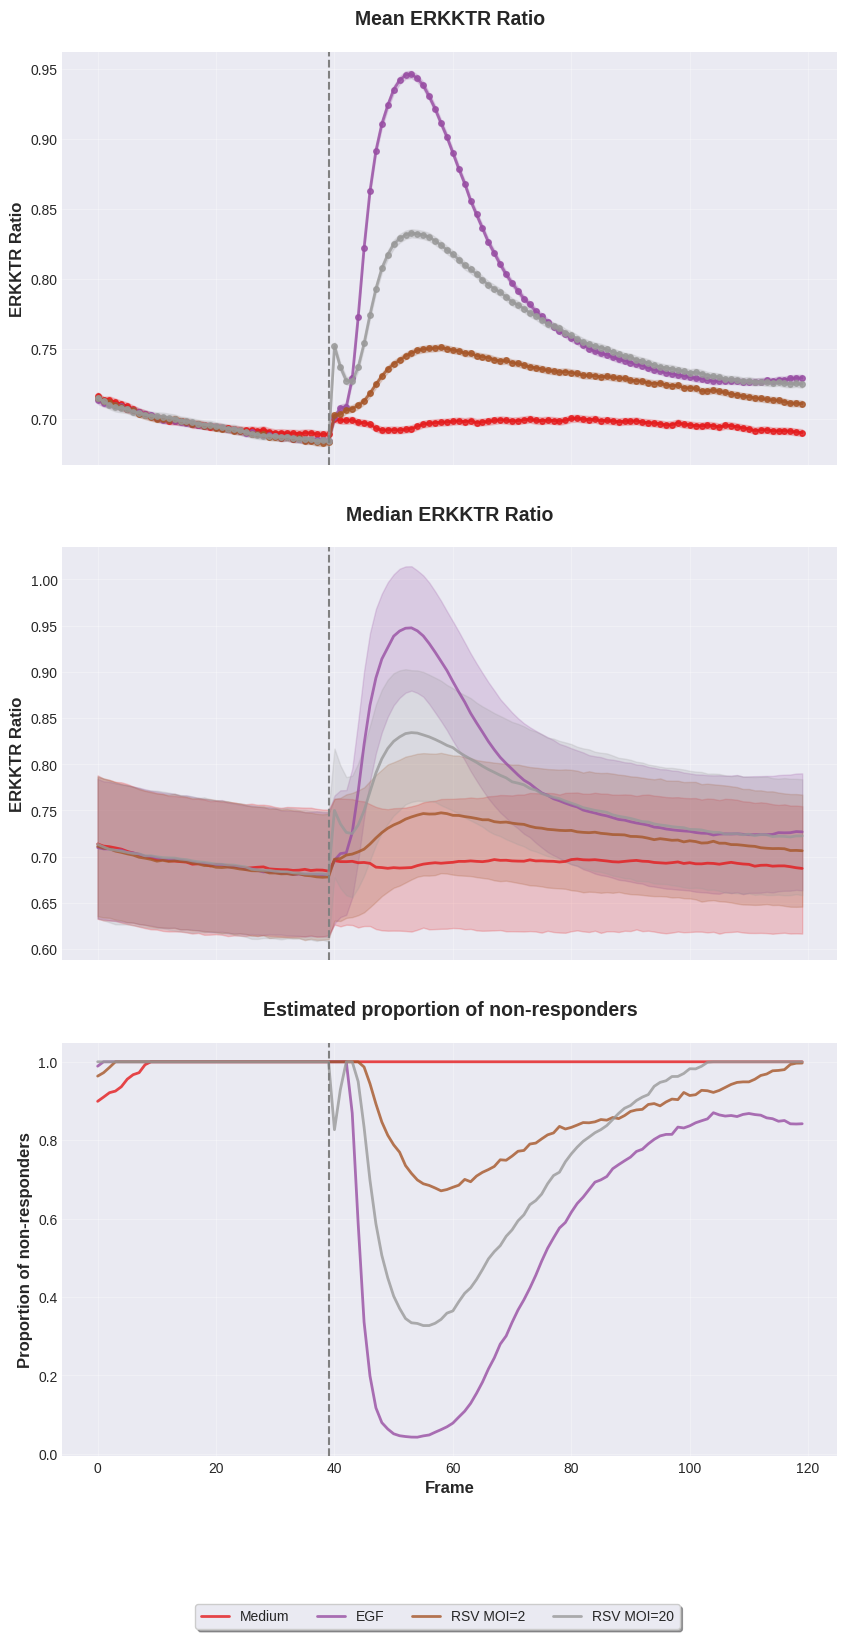

Combined plots saved to: combined_erkktr_plots.png


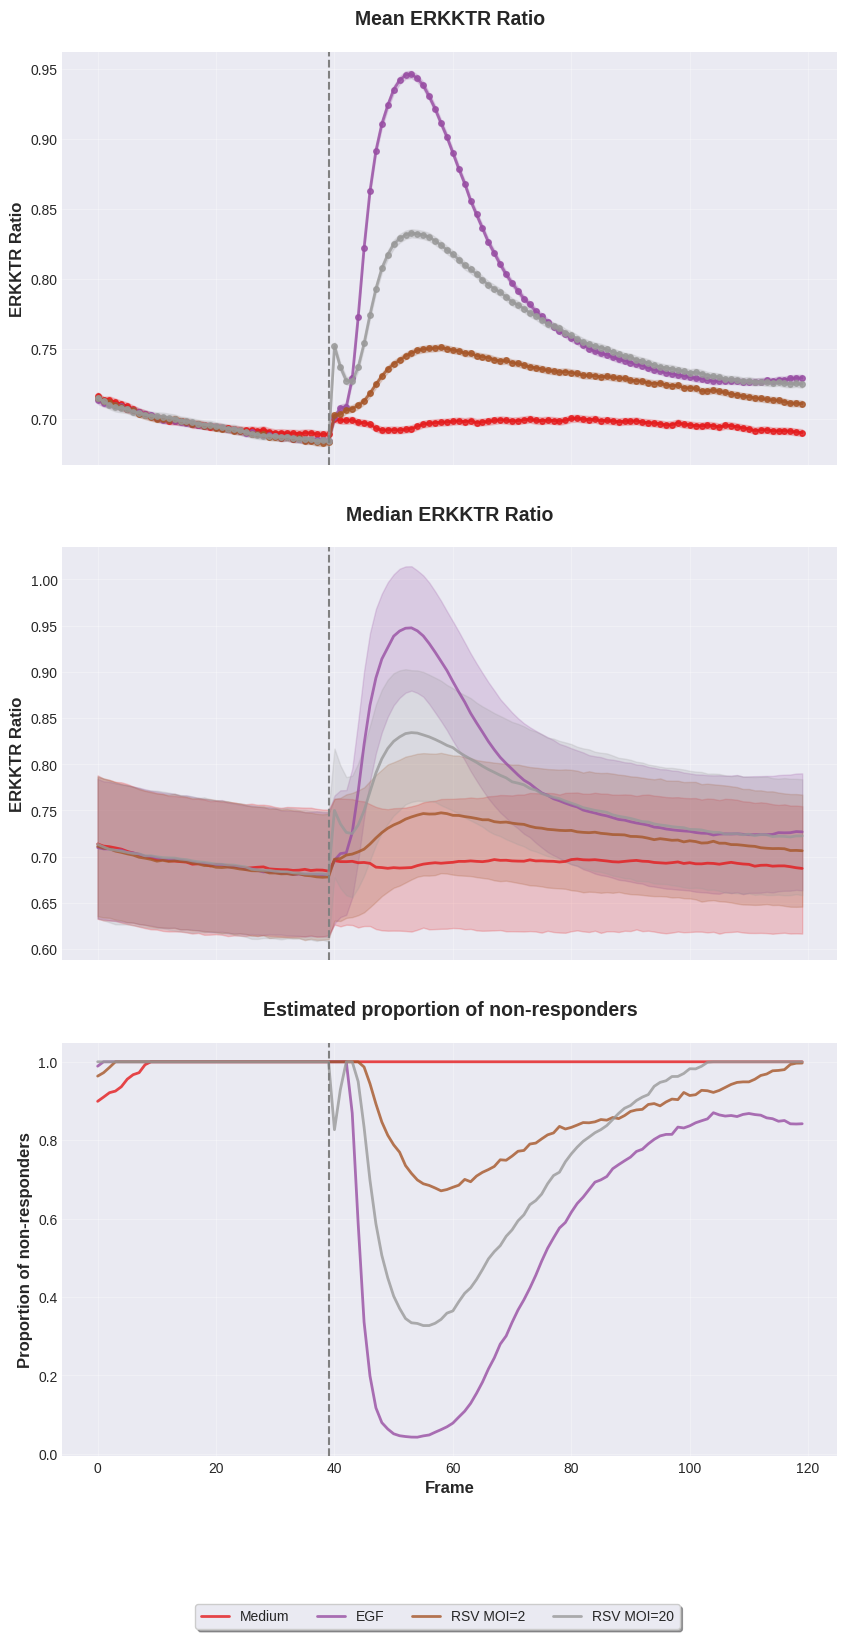

In [192]:
create_combined_erkktr_plots(df, 39)

Medium
EGF
RSV MOI=2
RSV MOI=20


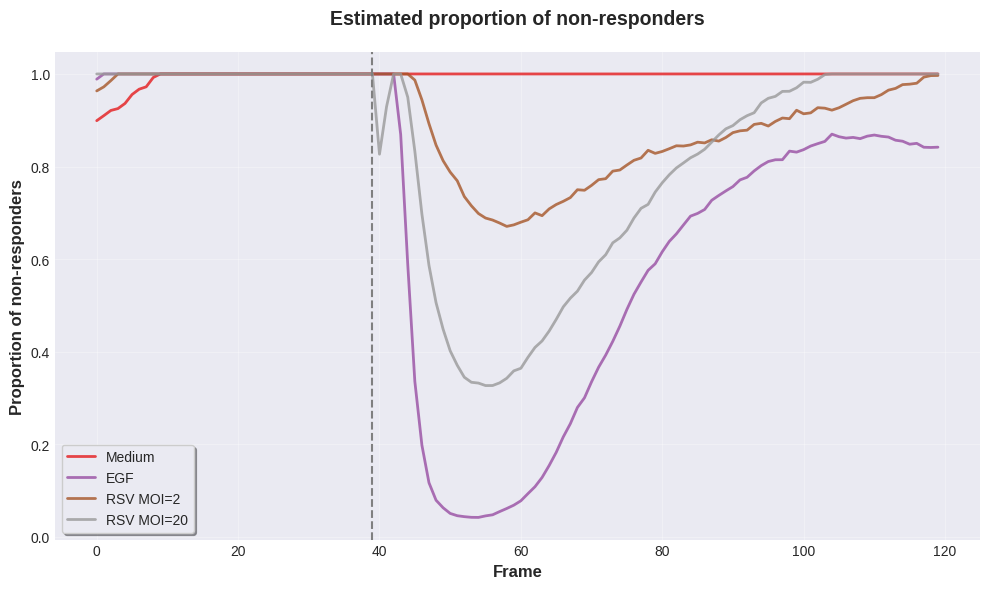

In [172]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats

# Set style for better aesthetics
plt.style.use('seaborn-v0_8-darkgrid')  # or 'seaborn-v0_8-whitegrid'
colors = plt.cm.Set1(np.linspace(0, 1, df['well'].nunique()))

fig, ax = plt.subplots(figsize=(10, 6))

for i, (well_id, well) in enumerate(df.groupby('well')):
    # Group by frame and calculate statistics
    frame_stats = ratio_of_responders(well)
    # Plot line with semi-transparent confidence interval
    color = colors[i]
    treatment = well['CellType1'].iloc[0]
    print(treatment)
    # Main line
    ax.plot(frame_stats['frame'], frame_stats['above'], 
            color=color, linewidth=2, label=treatment, 
             alpha=0.8)

ax.axvline(x = 39, color='grey', linestyle='--')
# Styling
ax.set_xlabel('Frame', fontsize=12, fontweight='bold')
ax.set_ylabel('Proportion of non-responders', fontsize=12, fontweight='bold')
ax.set_title('Estimated proportion of non-responders', 
             fontsize=14, fontweight='bold', pad=20)

# Legend with only main lines (not CI)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='best', frameon=True, 
          fancybox=True, shadow=True)

# Grid and layout
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()#savefig('/mnt/nas/group/pkaczyns/ERKKTR/')

In [23]:
df_st = pd.read_csv(r"/mnt/nas/group/REPORT/Imaging/2025-05-29-namirine-A549 ERKKTR mRUBY clone4, RSV NB6 MOI=2, 20/quantifications.csv")

In [25]:
df_st['ERKKTR_ratio'] = df_st['ERKKTR_intensity_mean_per']/df_st['ERKKTR_intensity_mean']

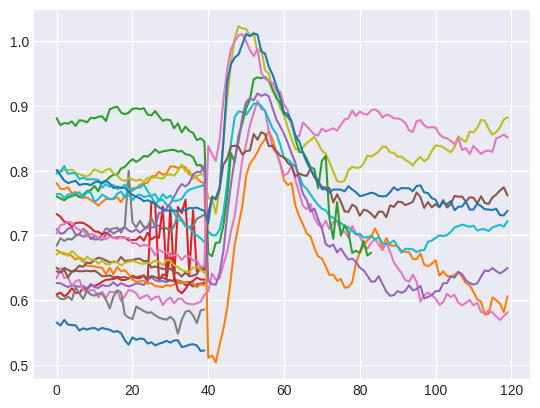

In [36]:
for i, track_wth_id in enumerate(df[df['well'] == '0305'].sort_values('frame').groupby(['track_id'])):
    id,track = track_wth_id
    plt.plot(track['frame'], track['ERKKTR_ratio'])
    if i==20:
        break

In [46]:
df

,track_id,frame,nuc_id,y,x,nuc_area,nuc_H2B_intensity_mean,nuc_H2B_intensity_sum,nuc_H2B_intensity_max,nuc_H2B_intensity_min,...,per_H2B_intensity_mean,per_H2B_intensity_sum,per_H2B_intensity_max,per_H2B_intensity_min,per_ERKKTR_intensity_mean,per_ERKKTR_intensity_sum,per_ERKKTR_intensity_max,per_ERKKTR_intensity_min,well,ERKKTR_ratio
0,1,0,1,2800.842697,1086.309925,1068,1429.157303,1526340,2009,703,...,511.183908,177892.0,770.0,403.0,1586.804598,552208.0,2056.0,980.0,0205,0.541261
1,1,1,3,2798.765421,1085.427103,1070,1420.446729,1519878,2096,681,...,507.411079,174042.0,745.0,391.0,1607.064140,551223.0,2041.0,889.0,0205,0.543215
2,1,2,4,2798.214353,1085.180359,1059,1421.901794,1505794,2004,696,...,517.578488,178047.0,746.0,416.0,1631.764535,561327.0,2252.0,1001.0,0205,0.546967
3,1,3,2,2798.454884,1085.567442,1075,1410.453023,1516237,1938,663,...,508.776471,172984.0,782.0,421.0,1625.594118,552702.0,2042.0,1046.0,0205,0.541329
4,1,4,3,2798.022556,1084.678571,1064,1408.216165,1498342,1972,674,...,508.055556,173755.0,646.0,387.0,1650.257310,564388.0,2063.0,1155.0,0205,0.545095
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
672880,11900,119,5877,3087.454167,1617.658333,240,596.479167,143155,713,438,...,460.545455,60792.0,571.0,389.0,1232.568182,162699.0,2011.0,816.0,0307,0.737656
672881,11901,119,5888,6.711340,3118.175258,194,571.262887,110825,717,422,...,457.691358,37073.0,561.0,391.0,942.123457,76312.0,2270.0,513.0,0307,0.417193
672882,11902,119,5907,3178.885542,2885.337349,166,642.397590,106638,796,477,...,512.856115,71287.0,778.0,370.0,2085.762590,289921.0,2501.0,1506.0,0307,0.866378
672883,11903,119,5910,2497.369048,281.559524,252,702.210317,176957,922,507,...,473.339623,50174.0,555.0,405.0,2456.443396,260383.0,3013.0,1696.0,0307,0.735110


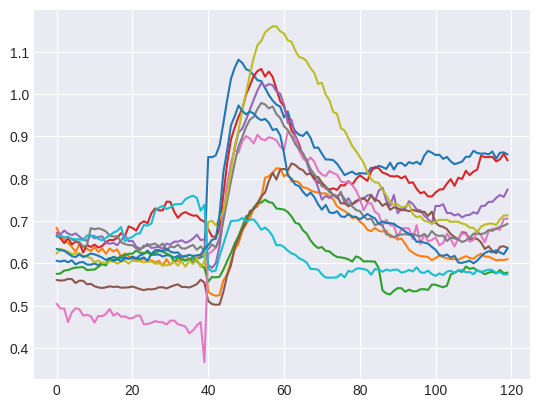

In [44]:
for i, track_wth_id in enumerate(df_st[df_st['well'] == 305].sort_values('time_point_index').groupby(['track_index'])):
    id,track = track_wth_id
    plt.plot(track['time_point_index'], track['ERKKTR_ratio'])
    if i==10:
        break

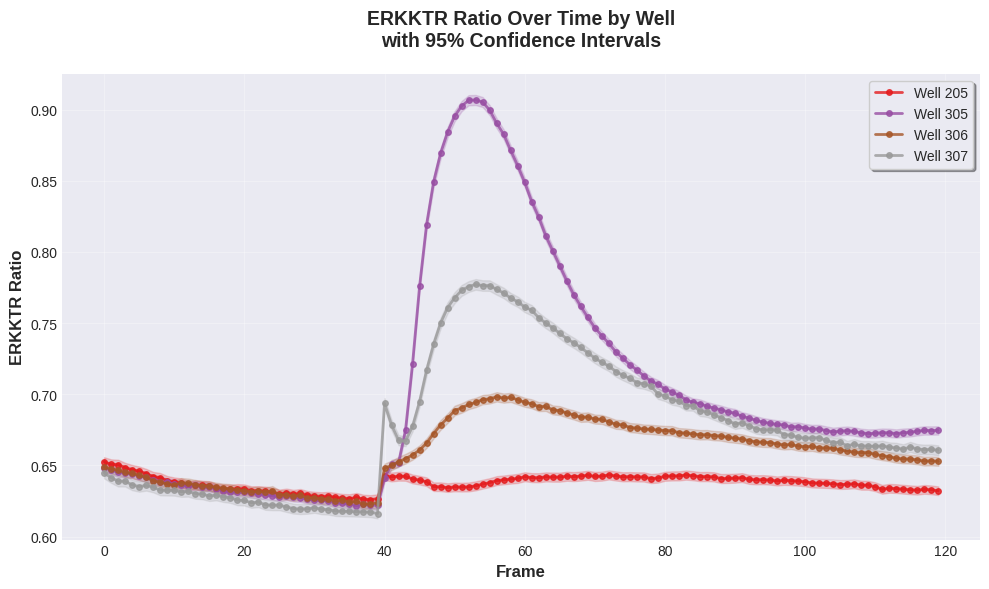

"\nfig2, ax2 = plt.subplots(figsize=(10, 6))\n\nfor i, (well_id, well) in enumerate(df.groupby('well')):\n    frame_stats = well.groupby('frame')['ERKKTR_ratio'].agg([\n        'mean', 'sem', 'count'\n    ]).reset_index()\n\n    # 95% confidence intervals\n    ci = stats.t.ppf(0.975, frame_stats['count'] - 1) * frame_stats['sem']\n\n    color = colors[i]\n    ax2.errorbar(frame_stats['frame'], frame_stats['mean'], \n                yerr=ci, color=color, linewidth=2, \n                label=f'Well {well_id}', marker='o', markersize=4,\n                capsize=3, capthick=1, alpha=0.8)\n\nax2.set_xlabel('Frame', fontsize=12, fontweight='bold')\nax2.set_ylabel('ERKKTR Ratio', fontsize=12, fontweight='bold')\nax2.set_title('ERKKTR Ratio Over Time by Well\nwith 95% Confidence Intervals', \n              fontsize=14, fontweight='bold')\nax2.legend(loc='best')\nax2.grid(True, alpha=0.3)\nplt.tight_layout()\nplt.show()\n"

In [ ]:

# Set style for better aesthetics
plt.style.use('seaborn-v0_8-darkgrid')  # or 'seaborn-v0_8-whitegrid'
colors = plt.cm.Set1(np.linspace(0, 1, df['well'].nunique()))

fig, ax = plt.subplots(figsize=(10, 6))

for i, (well_id, well) in enumerate(df_st.groupby('well')):
    # Group by frame and calculate statistics
    frame_stats = well.groupby('time_point_index')['ERKKTR_ratio'].agg([
        'mean', 'std', 'sem', 'count'
    ]).reset_index()
    
    # Calculate 95% confidence intervals using SEM and t-distribution
    confidence_level = 0.95
    alpha = 1 - confidence_level
    
    # Use t-distribution for small sample sizes, normal for large
    ci_multiplier = np.where(
        frame_stats['count'] < 30,
        stats.t.ppf(1 - alpha/2, frame_stats['count'] - 1),
        stats.norm.ppf(1 - alpha/2)
    )
    
    ci = ci_multiplier * frame_stats['sem']
    
    # Plot line with semi-transparent confidence interval
    color = colors[i]
    
    # Main line
    ax.plot(frame_stats['time_point_index'], frame_stats['mean'], 
            color=color, linewidth=2, label=f'Well {well_id}', 
            marker='o', markersize=4, alpha=0.8)
    
    # Semi-transparent confidence interval
    ax.fill_between(frame_stats['time_point_index'], 
                    frame_stats['mean'] - ci,
                    frame_stats['mean'] + ci,
                    color=color, alpha=0.2, 
                    label=f'Well {well_id} 95% CI')

# Styling
ax.set_xlabel('Frame', fontsize=12, fontweight='bold')
ax.set_ylabel('ERKKTR Ratio', fontsize=12, fontweight='bold')
ax.set_title('ERKKTR Ratio Over Time by Well\nwith 95% Confidence Intervals', 
             fontsize=14, fontweight='bold', pad=20)

# Legend with only main lines (not CI)
handles, labels = ax.get_legend_handles_labels()
# Keep only every other handle/label (the main lines, not CI)
main_handles = handles[::2]
main_labels = labels[::2]
ax.legend(main_handles, main_labels, loc='best', frameon=True, 
          fancybox=True, shadow=True)

# Grid and layout
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()



# MOI threshold

In [ ]:
quant_path = r"/mnt/data/"

In [8]:
exp_path = "/mnt/nas/operetta/namirine/Processing/mRUBY/2025-06-30-Thereshold for MOI"

In [9]:
extract_wells_info(exp_path).rename({'Virus':'Serum', 'CellType1': 'treatment', 'CellType2': 'CellType'},axis=1)

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/nas/operetta/namirine/Processing/mRUBY/2025-06-30-Thereshold for MOI/WellsInfo.html'

In [ ]:
#Plot of max intensity vs MOI
def plot_quant(df):
    df

In [ ]:
# Set style for better aesthetics
plt.style.use('seaborn-v0_8-darkgrid')  # or 'seaborn-v0_8-whitegrid'
colors = plt.cm.Set1(np.linspace(0, 1, df['well'].nunique()))

fig, ax = plt.subplots(figsize=(10, 6))

for i, (well_id, well) in enumerate(df_st.groupby('well')):
    # Group by frame and calculate statistics
    frame_stats = well.groupby('time_point_index')['ERKKTR_ratio'].agg([
        'mean', 'std', 'sem', 'count'
    ]).reset_index()
    
    # Calculate 95% confidence intervals using SEM and t-distribution
    confidence_level = 0.95
    alpha = 1 - confidence_level
    
    # Use t-distribution for small sample sizes, normal for large
    ci_multiplier = np.where(
        frame_stats['count'] < 30,
        stats.t.ppf(1 - alpha/2, frame_stats['count'] - 1),
        stats.norm.ppf(1 - alpha/2)
    )
    
    ci = ci_multiplier * frame_stats['sem']
    
    # Plot line with semi-transparent confidence interval
    color = colors[i]
    
    # Main line
    ax.plot(frame_stats['time_point_index'], frame_stats['mean'], 
            color=color, linewidth=2, label=f'Well {well_id}', 
            marker='o', markersize=4, alpha=0.8)
    
    # Semi-transparent confidence interval
    ax.fill_between(frame_stats['time_point_index'], 
                    frame_stats['mean'] - ci,
                    frame_stats['mean'] + ci,
                    color=color, alpha=0.2, 
                    label=f'Well {well_id} 95% CI')

# Styling
ax.set_xlabel('Frame', fontsize=12, fontweight='bold')
ax.set_ylabel('ERKKTR Ratio', fontsize=12, fontweight='bold')
ax.set_title('ERKKTR Ratio Over Time by Well\nwith 95% Confidence Intervals', 
             fontsize=14, fontweight='bold', pad=20)

# Legend with only main lines (not CI)
handles, labels = ax.get_legend_handles_labels()
# Keep only every other handle/label (the main lines, not CI)
main_handles = handles[::2]
main_labels = labels[::2]
ax.legend(main_handles, main_labels, loc='best', frameon=True, 
          fancybox=True, shadow=True)

# Grid and layout
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
